# PAPA Ocean Station Sea Surface Temperature: Observational vs Access-om2 model data

To try and diagnose the innacuracies identified in the flux figures, this notebook plots the SST of PAPA ocean station and the corresponding Access-om2 output for 3 different resolutions.

In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 1
Total threads: 1,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44923,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43127,Total threads: 1
Dashboard: /proxy/39319/status,Memory: 63.00 GiB
Nanny: tcp://127.0.0.1:38199,


In [3]:
PAPA_DIR = "/g/data/jk72/ob1561"
papa_sst_file = os.path.join(PAPA_DIR, "sst50n145w_dy.cdf")

ds_sst = xr.open_dataset(papa_sst_file)

print(ds_sst)
print("\nData variables:", list(ds_sst.data_vars))
print("Coordinates:", list(ds_sst.coords))

print("\Sea surface temperature variable details:")
for v in ds_sst.data_vars:
    print(f"\n--- {v} ---")
    print(ds_sst[v])
    print("Attrs:", ds_sst[v].attrs)
    print("Min / max (raw):",
          float(ds_sst[v].min()), float(ds_sst[v].max()))

ds_sst.close()

<xarray.Dataset> Size: 117kB
Dimensions:  (time: 5855, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 47kB 2010-01-01T12:00:00 ... 2026-01-11T12...
  * depth    (depth) float32 4B 1.0
  * lat      (lat) float32 4B 50.1
  * lon      (lon) float32 4B 215.1
Data variables:
    T_25     (time, depth, lat, lon) float32 23kB ...
    QT_5025  (time, depth, lat, lon) float32 23kB ...
    ST_6025  (time, depth, lat, lon) float32 23kB ...
Attributes:
    Data_Source:    OCS Project Office/NOAA/PMEL
    OCS:            Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:      Contact: Dai.C.McClurg@noaa.gov
    missing_value:  1e+35
    _FillValue:     1e+35
    CREATION_DATE:  15:12 11-JAN-2026

Data variables: ['T_25', 'QT_5025', 'ST_6025']
Coordinates: ['time', 'depth', 'lat', 'lon']
\Sea surface temperature variable details:

--- T_25 ---
<xarray.DataArray 'T_25' (time: 5855, depth: 1, lat: 1, lon: 1)> Size: 23kB
[5855 values with dtype=float32]
Coordinates

In [4]:
print('Starting ACCESS-OM2 and PAPA SST analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri

#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2 
#----------------------------------------------------------------------------------------------

var    =  'sst'
var_01 = 'surface_pot_temp'

experiments = ['1deg_jra55_iaf_omip2_cycle6', '025deg_jra55_iaf_omip2_cycle6', ['01deg_jra55v140_iaf_cycle4', '01deg_jra55v140_iaf_cycle4_jra55v150_extension']]

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

papa_var   =  'T_25'

#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat = np.array([49, 51])        # yt_ocean, N (band around 50N)
region_lon = np.array([213, 217])      # xt_ocean, E  (213–217E == 147–143W)
region_lon = region_lon - 360                        # -> [-213, -205]

region = [region_lat, region_lon]

Starting ACCESS-OM2 and PAPA SST analysis.


In [5]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var_01,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")

Processing ACCESS sst data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [6]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    if exp == "01deg_jra55v140_iaf_cycle4":
        var = var_01
        
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    monthly_climatology = heat_flux.groupby('time.month').mean(dim='time')

    exp_heat_flux[exp] = {
        "monthly_mean": monthly_climatology}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()

Start collecting sst 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sst data for ACCESS.
Execution time: 0.03 minutes
Start collecting sst 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sst data for ACCESS.
Execution time: 0.04 minutes
Start collecting surface_pot_temp 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting surface_pot_temp data for ACCESS.
Execution time: 0.43 minutes


In [7]:
# --------------------------------------------------------------------------
# Read and collect data for PAPA (SST)
# --------------------------------------------------------------------------

print("Processing PAPA SST data...")
sys.stdout.flush()

PAPA_DIR = "/g/data/jk72/ob1561"
papa_sst_file = os.path.join(PAPA_DIR, "sst50n145w_dy.cdf")

start = time.time()

ds_papa = xr.open_dataset(papa_sst_file)

# SST variable (°C) with singleton dims -> 1D time series
papa_sst = ds_papa[papa_var].isel(depth=0, lat=0, lon=0)

# Mask fill values (1e35)
fill = papa_sst.attrs.get("missing_value", 1e35)
papa_sst = papa_sst.where(papa_sst != fill)

# Match ACCESS time window
papa_sst = papa_sst.sel(time=slice(start_date, end_date))

# Monthly climatology (same structure as SOTS_monthly_climatology in the example)
papa_monthly_climatology = papa_sst.groupby("time.month").mean(dim="time", skipna=True)

print(papa_monthly_climatology.values)

ds_papa.close()

end = time.time()
print("Finished collecting PAPA SST data.")
print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()


Processing PAPA SST data...
[ 6.883871   6.470405   6.1437097  6.4333906  7.5185432  9.357079
 11.853449  14.131862  14.0185    11.922926   9.608143   7.9357276]
Finished collecting PAPA SST data.
Execution time: 0.00 minutes


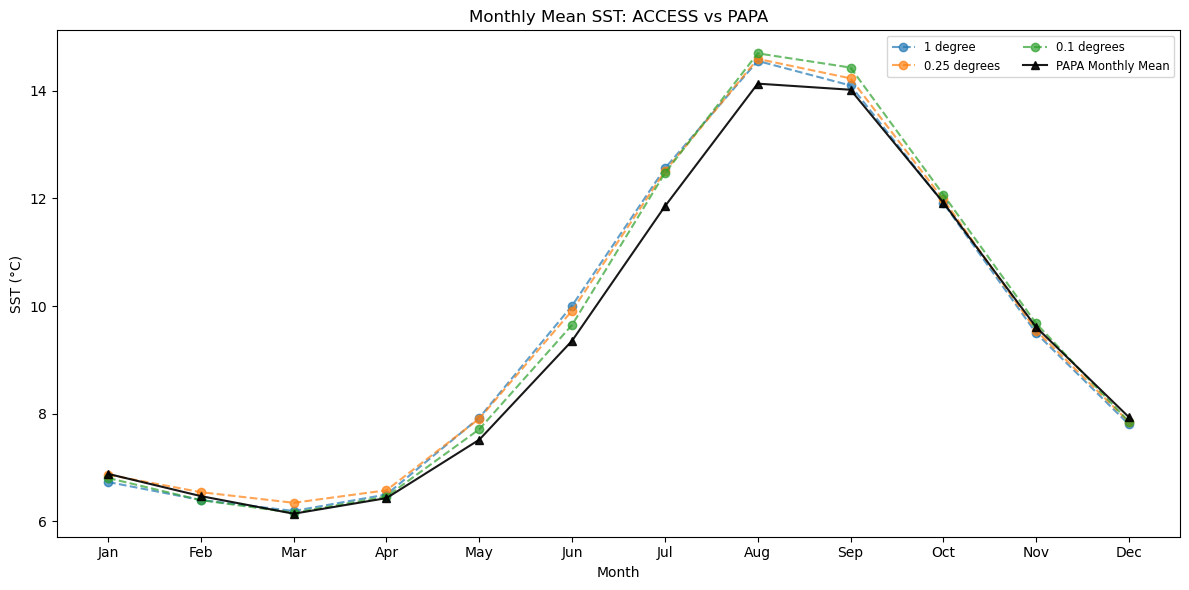

In [8]:
# --------------------------------------------------------------------------
# PLOT
# --------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

exp_titles = {
    "1deg_jra55_iaf_omip2_cycle6": "1 degree",
    "025deg_jra55_iaf_omip2_cycle6": "0.25 degrees",
    "01deg_jra55v140_iaf_cycle4": "0.1 degrees",
}

for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict["monthly_mean"] - 273.15  # convert K -> °C for ACCESS
    label = exp_titles.get(exp_name, exp_name)

    ax.plot(
        monthly_mean["month"],
        monthly_mean.values,
        marker="o",
        linestyle="--",
        alpha=0.7,
        label=label,
    )

# PAPA monthly climatology (already °C)
ax.plot(
    papa_monthly_climatology["month"],
    papa_monthly_climatology.values,
    color="black",
    marker="^",
    linestyle="-",
    alpha=0.9,
    label="PAPA Monthly Mean",
)

ax.set_xlabel("Month")
ax.set_ylabel("SST (°C)")
ax.set_title("Monthly Mean SST: ACCESS vs PAPA")
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

ax.legend(ncol=2, fontsize="small", loc="best")
plt.tight_layout()
plt.show()
